# 0.1. Przygotowanie środowiska

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve() / "src"))

from config.config import setup

cfg = setup()

HAR_ROOT = cfg["HAR_ROOT"]
MODELS_DIR = cfg["MODELS_DIR"]
RESULTS_DIR = cfg["RESULTS_DIR"]
FIGURES_DIR = cfg["FIGURES_DIR"]
PROJECT_ROOT = cfg["PROJECT_ROOT"]

# 0.2. Wgranie danych

In [2]:
import numpy as np
from data.loader import load_har_data

X_train, y_train, groups_train, X_test, y_test, groups_test, feature_names = (
    load_har_data(HAR_ROOT)
)

y_test_arr = np.asarray(y_test)
classes = sorted(y_test.unique().tolist())

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Klasy ({len(classes)}): {classes}")

LABEL_NAMES = {
    1: "WALKING",
    2: "WALKING_UP",
    3: "WALKING_DOWN",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING",
}


def short_label(label):
    return label.replace("WALKING_UPSTAIRS", "WALKING_UP").replace(
        "WALKING_DOWNSTAIRS", "WALKING_DOWN"
    )


short_classes = [short_label(c) for c in classes]

X_train: (7352, 561) | X_test: (2947, 561)
Klasy (6): ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


# 0.3. Wczytanie manifestu z Fazy 5

In [3]:
import json

manifest_path = MODELS_DIR / "05_phase_final_models" / "final_models_index.json"
with open(manifest_path) as f:
    final_models_index = json.load(f)
print(f"Zaladowano manifest dla {len(final_models_index)} modeli:")
for name, path in final_models_index.items():
    print(f"  {name:<18} -> {path}")

Zaladowano manifest dla 6 modeli:
  dummy              -> models/03_phase_dummy/grid_dummy.joblib
  logreg             -> models/03_phase_logreg/grid_logreg.joblib
  linear_svc         -> models/03_phase_linear_svc/grid_linear_svc.joblib
  rbf_svc            -> models/03_phase_rbf_svc/grid_rbf_svc.joblib
  random_forest      -> models/03_phase_random_forest/grid_random_forest.joblib
  gaussian_nb        -> models/03_phase_gaussian_nb/grid_gaussian_nb.joblib


# 1. Ładowanie modeli końcowych

In [4]:
import joblib

final_models = {}
for name, rel_path in final_models_index.items():
    grid = joblib.load(PROJECT_ROOT / rel_path)
    final_models[name] = grid.best_estimator_
    print(f"[OK] {name}")

[OK] dummy
[OK] logreg
[OK] linear_svc
[OK] rbf_svc
[OK] random_forest
[OK] gaussian_nb


# 2. Predykcja na X_test

In [5]:
predictions = {}
for name, estimator in final_models.items():
    y_pred = estimator.predict(X_test)
    y_proba = None
    if hasattr(estimator, "predict_proba"):
        try:
            y_proba = estimator.predict_proba(X_test)
        except Exception:
            y_proba = None
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}
    print(f"[{name}] predykcja wykonana, ma_proba={y_proba is not None}")

[dummy] predykcja wykonana, ma_proba=True
[logreg] predykcja wykonana, ma_proba=True
[linear_svc] predykcja wykonana, ma_proba=False
[rbf_svc] predykcja wykonana, ma_proba=False
[random_forest] predykcja wykonana, ma_proba=True
[gaussian_nb] predykcja wykonana, ma_proba=True


In [6]:
import pandas as pd

PRED_DIR = RESULTS_DIR / "06_phase_predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

for name, pred in predictions.items():
    df_pred = pd.DataFrame({"y_true": y_test_arr, "y_pred": pred["y_pred"]})
    if pred["y_proba"] is not None:
        proba_cols = pd.DataFrame(
            pred["y_proba"],
            columns=[f"proba_{c}" for c in classes],
        )
        df_pred = pd.concat([df_pred, proba_cols], axis=1)
    df_pred.to_csv(PRED_DIR / f"predictions_{name}.csv", index=False)

print(f"Zapisano predykcje dla {len(predictions)} modeli do: {PRED_DIR}")

Zapisano predykcje dla 6 modeli do: /Users/aleks/PycharmProjects/JupyterProjectHar/results/06_phase_predictions


# 3. Liczenie metryk

In [7]:
import pandas as pd
from sklearn.metrics import (
    matthews_corrcoef,
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
)


def compute_metrics(y_true, y_pred, y_proba=None):
    m = {
        "mcc": matthews_corrcoef(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
    }
    if y_proba is not None:
        try:
            m["roc_auc_ovr"] = roc_auc_score(
                y_true, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            m["roc_auc_ovr"] = None
    else:
        m["roc_auc_ovr"] = None
    return m


rows = []
for name, pred in predictions.items():
    m = compute_metrics(y_test_arr, pred["y_pred"], pred["y_proba"])
    rows.append({"model": name, **m})

df_metrics = (
    pd.DataFrame(rows).sort_values("mcc", ascending=False).reset_index(drop=True)
)

print(df_metrics.round(4).to_string(index=False))

METRICS_DIR = RESULTS_DIR / "06_phase_test_metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
df_metrics.to_csv(METRICS_DIR / "test_metrics.csv", index=False)
print(f"\nZapisano: {METRICS_DIR / 'test_metrics.csv'}")

        model     mcc  f1_macro  balanced_accuracy  accuracy  roc_auc_ovr
   linear_svc  0.9547    0.9629             0.9621    0.9620          NaN
       logreg  0.9469    0.9554             0.9543    0.9555       0.9976
      rbf_svc  0.9460    0.9543             0.9533    0.9549          NaN
random_forest  0.9146    0.9268             0.9257    0.9287       0.9956
  gaussian_nb  0.7648    0.7902             0.7937    0.8005       0.9626
        dummy -0.0071    0.1602             0.1606    0.1605       0.5000

Zapisano: /Users/aleks/PycharmProjects/JupyterProjectHar/results/06_phase_test_metrics/test_metrics.csv


# 4. Macierze pomyłek

## 4.1. Indywidualne wykresy (2 panele: liczby + znormalizowana)

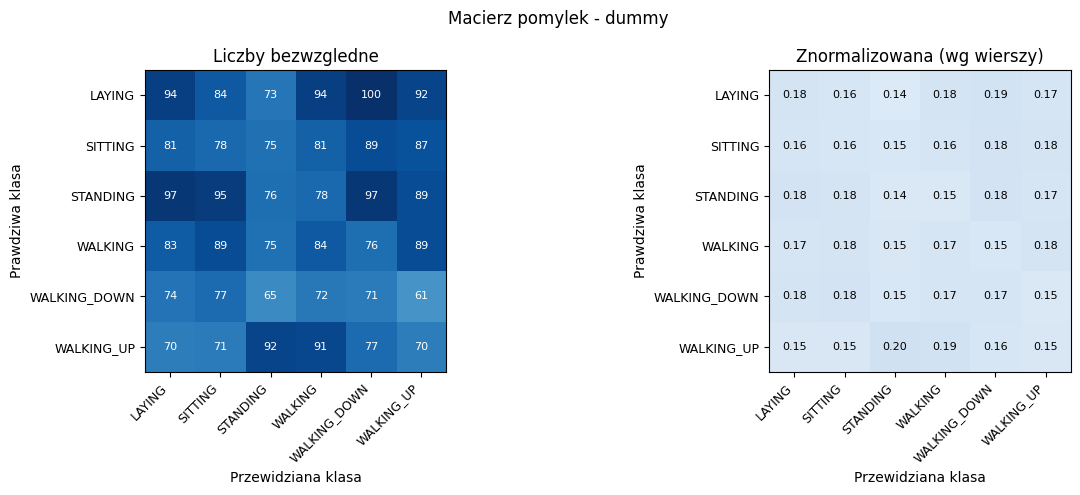

Zapisano: 06_phase_cm_dummy.png


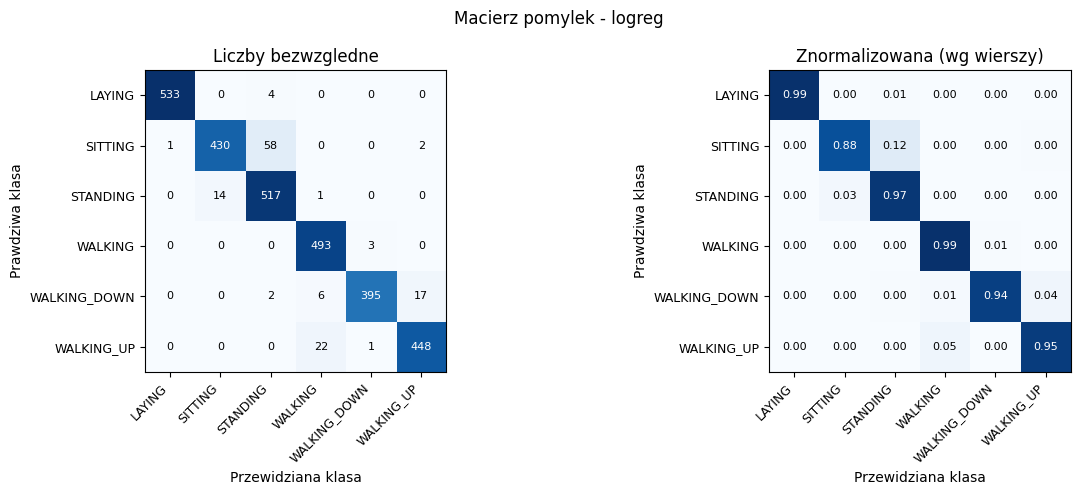

Zapisano: 06_phase_cm_logreg.png


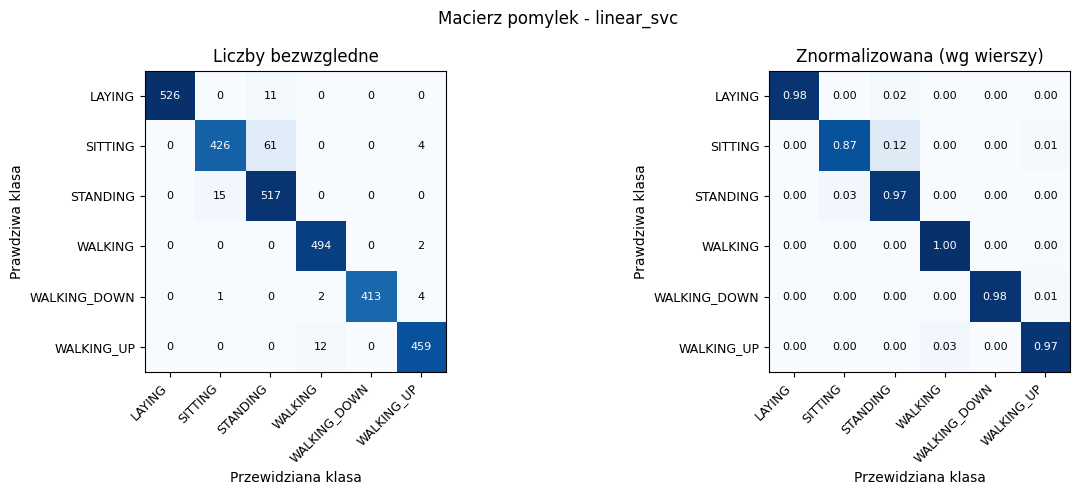

Zapisano: 06_phase_cm_linear_svc.png


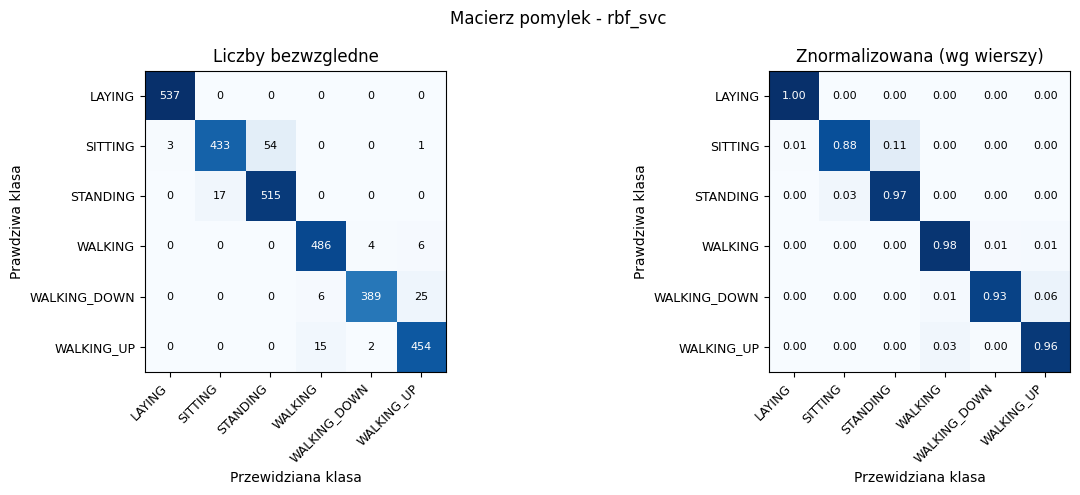

Zapisano: 06_phase_cm_rbf_svc.png


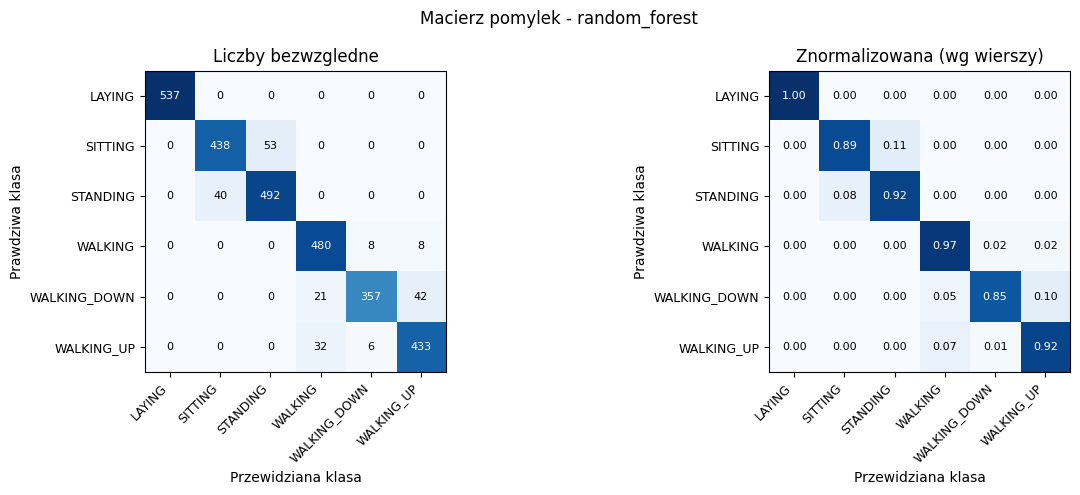

Zapisano: 06_phase_cm_random_forest.png


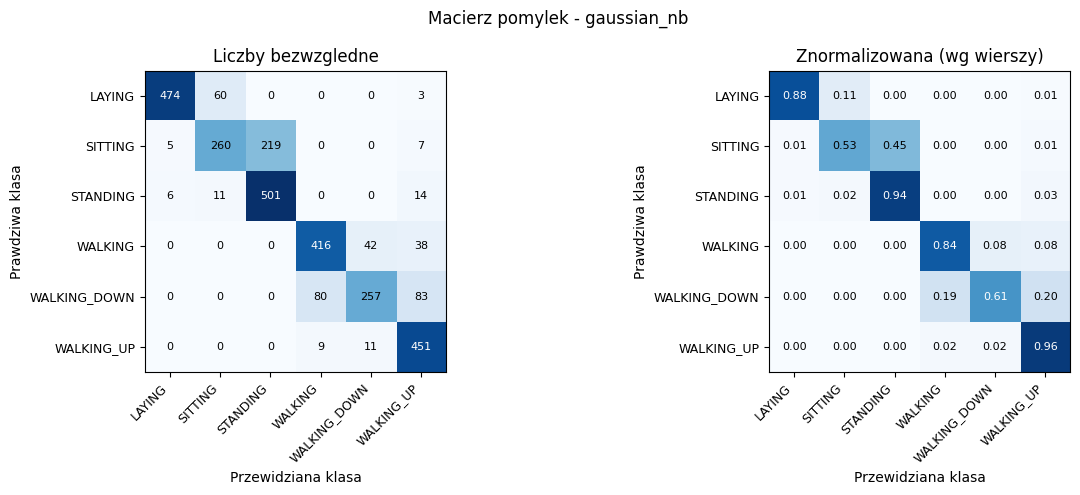

Zapisano: 06_phase_cm_gaussian_nb.png


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for name in final_models:
    y_pred = predictions[name]["y_pred"]
    cm = confusion_matrix(y_test_arr, y_pred, labels=classes)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    for ax, data, title in [
        (ax1, cm, "Liczby bezwzgledne"),
        (ax2, cm_norm, "Znormalizowana (wg wierszy)"),
    ]:
        vmax = int(data.max()) if data is cm else 1.0
        ax.imshow(data, cmap="Blues", vmin=0, vmax=vmax)
        ax.set_xticks(range(len(classes)))
        ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(short_classes, rotation=45, ha="right", fontsize=9)
        ax.set_yticklabels(short_classes, fontsize=9)
        ax.set_xlabel("Przewidziana klasa")
        ax.set_ylabel("Prawdziwa klasa")
        ax.set_title(title)
        for i in range(len(classes)):
            for j in range(len(classes)):
                val = data[i, j]
                text = str(val) if data is cm else f"{val:.2f}"
                color = "white" if val > vmax * 0.6 else "black"
                ax.text(j, i, text, ha="center", va="center", fontsize=8, color=color)

    fig.suptitle(f"Macierz pomylek - {name}", fontsize=12)
    fig.tight_layout()
    out = FIGURES_DIR / f"06_phase_cm_{name}.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Zapisano: {out.name}")

## 4.2. Zbiorczy panel 2x3 (znormalizowane)

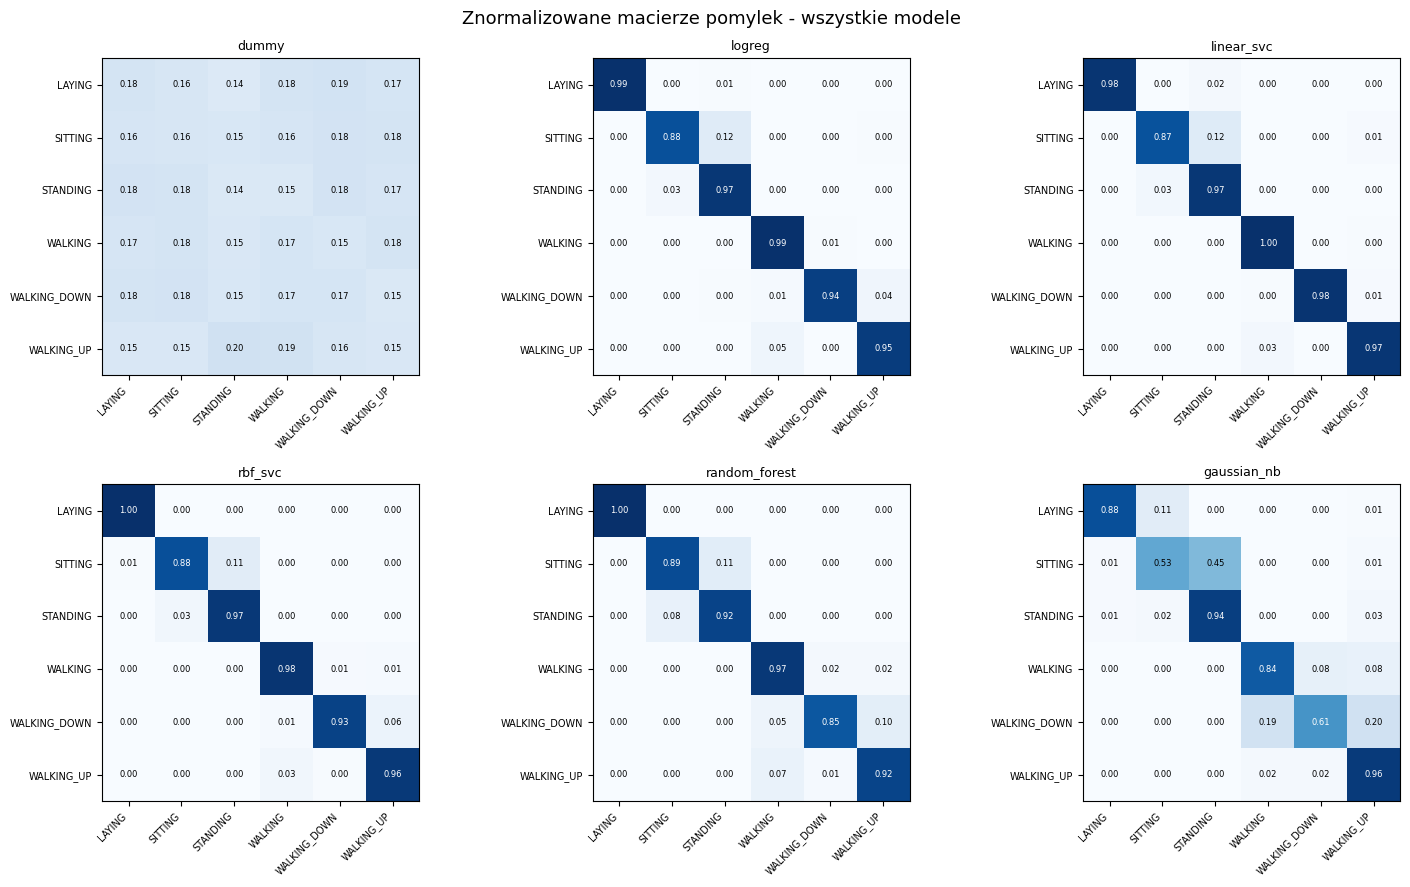

Zapisano: 06_phase_cm_all.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()

for idx, name in enumerate(final_models):
    ax = axes_flat[idx]
    y_pred = predictions[name]["y_pred"]
    cm = confusion_matrix(y_test_arr, y_pred, labels=classes)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(short_classes, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(short_classes, fontsize=7)
    ax.set_title(name, fontsize=9)
    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm_norm[i, j]
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=6,
                color="white" if val > 0.6 else "black",
            )

fig.suptitle("Znormalizowane macierze pomylek - wszystkie modele", fontsize=13)
fig.tight_layout()
out_all = FIGURES_DIR / "06_phase_cm_all.png"
fig.savefig(out_all, dpi=120, bbox_inches="tight")
plt.show()
print(f"Zapisano: {out_all.name}")

# 5. Analiza typowych błędów

In [10]:
best_name = df_metrics.iloc[0]["model"]
y_pred_best = predictions[best_name]["y_pred"]
cm_best = confusion_matrix(y_test_arr, y_pred_best, labels=classes)

cm_errors = cm_best.copy()
np.fill_diagonal(cm_errors, 0)

flat_order = np.argsort(cm_errors.flatten())[::-1]

print(f"Top-5 pomylek dla modelu '{best_name}':")
shown = 0
for flat_idx in flat_order:
    if shown == 5:
        break
    i, j = divmod(int(flat_idx), len(classes))
    count = cm_errors[i, j]
    if count == 0:
        break
    print(f"  {classes[i]:<22} -> {classes[j]:<22}: {count:4d} bledow")
    shown += 1

Top-5 pomylek dla modelu 'linear_svc':
  SITTING                -> STANDING              :   61 bledow
  STANDING               -> SITTING               :   15 bledow
  WALKING_UPSTAIRS       -> WALKING               :   12 bledow
  LAYING                 -> STANDING              :   11 bledow
  SITTING                -> WALKING_UPSTAIRS      :    4 bledow


# 6. Porównanie CV-MCC vs test-MCC

In [11]:
cv_summary = pd.read_csv(
    RESULTS_DIR / "05_phase_final_models" / "final_models_summary.csv"
)
cv_dict = dict(zip(cv_summary["model"], cv_summary["cv_mcc"]))

delta_rows = []
for _, row in df_metrics.iterrows():
    name = row["model"]
    test_mcc = row["mcc"]
    cv_mcc = cv_dict.get(name, float("nan"))
    delta_rows.append(
        {
            "model": name,
            "cv_mcc": round(cv_mcc, 4),
            "test_mcc": round(test_mcc, 4),
            "delta": round(test_mcc - cv_mcc, 4),
        }
    )

df_delta = (
    pd.DataFrame(delta_rows)
    .sort_values("test_mcc", ascending=False)
    .reset_index(drop=True)
)
print(df_delta.to_string(index=False))

df_delta.to_csv(METRICS_DIR / "cv_vs_test_delta.csv", index=False)
print(f"\nZapisano: {METRICS_DIR / 'cv_vs_test_delta.csv'}")

        model  cv_mcc  test_mcc   delta
   linear_svc  0.9258    0.9547  0.0289
       logreg  0.9227    0.9469  0.0242
      rbf_svc  0.9177    0.9460  0.0283
random_forest  0.9041    0.9146  0.0105
  gaussian_nb  0.6911    0.7648  0.0737
        dummy  0.0034   -0.0071 -0.0105

Zapisano: /Users/aleks/PycharmProjects/JupyterProjectHar/results/06_phase_test_metrics/cv_vs_test_delta.csv
